In [10]:
library(tidyverse)
library(repr)
library(tidymodels)
options(repr.matrix.max.rows = 6)
library(janitor)



Attaching package: ‘janitor’


The following objects are masked from ‘package:stats’:

    chisq.test, fisher.test




Sanya Singh 49291222, section/group: 004-32
**(1) Data description**

Two datasets are provided:
- players.csv — contains demographic and behavioural information about each player.
- sessions.csv — contains data about individual gameplay sessions linked to players.

players.csv
- Number of observations: 196
- Number of variables: 7

Variables:
- experience: Player’s self-reported experience level (e.g., Amateur, Expert), categorical
- subscribe: Indicates if a player subscribed to the game newsletter, Boolean (TRUE/FALSE)
- played_hours: Total hours spent playing, numeric
- gender: reported gender, categorical
- Age: age in years, numeric
- hashedEmail: Unique identifier for linking with session data, string

Summary statistics:
- played_hours, mean = 5.85
- Age, mean = 21.14


sessions.csv
- Number of observations: 1,535
- Number of variables: 5

Variables:
- hashedEmail: Unique player identifier for joining with players.csv, string
- start_time and end_time: Recorded session times (in DD/MM/YYYY HH:MM format), string
- original_start_time and original_end_time: Unix timestamps representing session start and end, numeric

Summar statistics:
- original_start_time, mean = 1.719×10^12
- original_end_time, mean = 1.719×10^12

Relationships between datasets:
- Both datasets share the variable hashedEmail, which can be used to link players to their sessions.
- Only 125 out of 196 players have recorded session data, so not all players appear in both datasets.


**Data issues**
- Missing values: 2 missing age and 2 missing end_time values
- Skewed variables: played_hours  highly skewed — most players play <1 hour, few play hundreds of hours.
- Imbalance: Possibly more subscribed players (144/196) — may bias models.
- Incomplete linkage: 196 players but only 125 appear in sessions; some players have no session data.
- Time formatting: Need to convert timestamps to proper datetime format and compute session duration.

**(2) Research question**: Can demographic factors (Age, gender) and experience level (experience) predict the total number of gameplay hours (played_hours) contributed by players in the players.csv dataset?
- played_hours (numeric) will act as a response variable, which is the total time (in hours) that a player has spent playing the game. This variable serves as a proxy for how much data a player contributes, therefore players who play more generate more session and behavioural data.

**Methodology**
- To address the question “Can demographic factors (Age, gender) and experience level predict total hours played by a player?”, I will use a Multivariable Linear Regression (MLR) model. This method estimates how several independent variables jointly influence a single numeric outcome variable (played_hours).
- Merge datasets (players.csv and sessions.csv) by hashedEmail to link demographics and session data
- Feature creation — compute session_count and mean_session_length from sessions.csv for possible inclusion as predictors.
- Data cleaning — handle missing values (e.g., impute missing Age), remove irrelevant columns (name, hashedEmail), and encode categorical variables as factors.
- Data splitting — divide the data into 70% training and 30% testing sets to evaluate model generalization.
- Model fitting and evaluation — train the regression model on the training set, then predict and evaluate played_hours on the test set using the selected metrics.

Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, Age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


experience,subscribe,hashedEmail,played_hours,name,gender,Age
<chr>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<dbl>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17
Veteran,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17
⋮,⋮,⋮,⋮,⋮,⋮,⋮
Amateur,FALSE,d572f391d452b76ea2d7e5e53a3d38bfd7499c7399db299bd4fedb06a46ad5bb,0.0,Dylan,Prefer not to say,57
Amateur,FALSE,f19e136ddde68f365afc860c725ccff54307dedd13968e896a9f890c40aea436,2.3,Harlow,Male,17
Pro,TRUE,d9473710057f7d42f36570f0be83817a4eea614029ff90cf50d8889cdd729d11,0.2,Ahmed,Other,NA


Rows: 1535 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): hashedEmail, start_time, end_time
dbl (2): original_start_time, original_end_time

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


hashedEmail,start_time,end_time,original_start_time,original_end_time
<chr>,<chr>,<chr>,<dbl>,<dbl>
bfce39c89d6549f2bb94d8064d3ce69dc3d7e72b38f431d8aa0c4bf95ccee6bf,30/06/2024 18:12,30/06/2024 18:24,1.71977e+12,1.71977e+12
36d9cbb4c6bc0c1a6911436d2da0d09ec625e43e6552f575d4acc9cf487c4686,17/06/2024 23:33,17/06/2024 23:46,1.71867e+12,1.71867e+12
f8f5477f5a2e53616ae37421b1c660b971192bd8ff77e3398304c7ae42581fdc,25/07/2024 17:34,25/07/2024 17:57,1.72193e+12,1.72193e+12
⋮,⋮,⋮,⋮,⋮
fd6563a4e0f6f4273580e5fedbd8dda64990447aea5a33cbb5e894a3867ca44d,28/07/2024 15:36,28/07/2024 15:57,1.72218e+12,1.72218e+12
fd6563a4e0f6f4273580e5fedbd8dda64990447aea5a33cbb5e894a3867ca44d,25/07/2024 06:15,25/07/2024 06:22,1.72189e+12,1.72189e+12
36d9cbb4c6bc0c1a6911436d2da0d09ec625e43e6552f575d4acc9cf487c4686,20/05/2024 02:26,20/05/2024 02:45,1.71617e+12,1.71617e+12


variable,mean_value
<chr>,<dbl>
played_hours,5.845918
age,21.139175


Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”


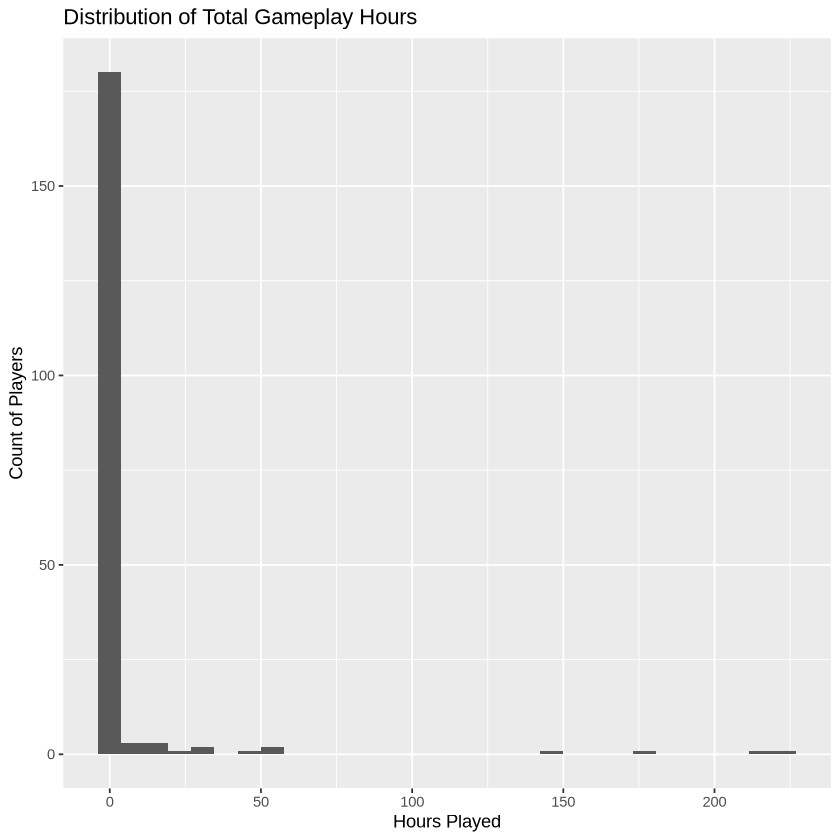

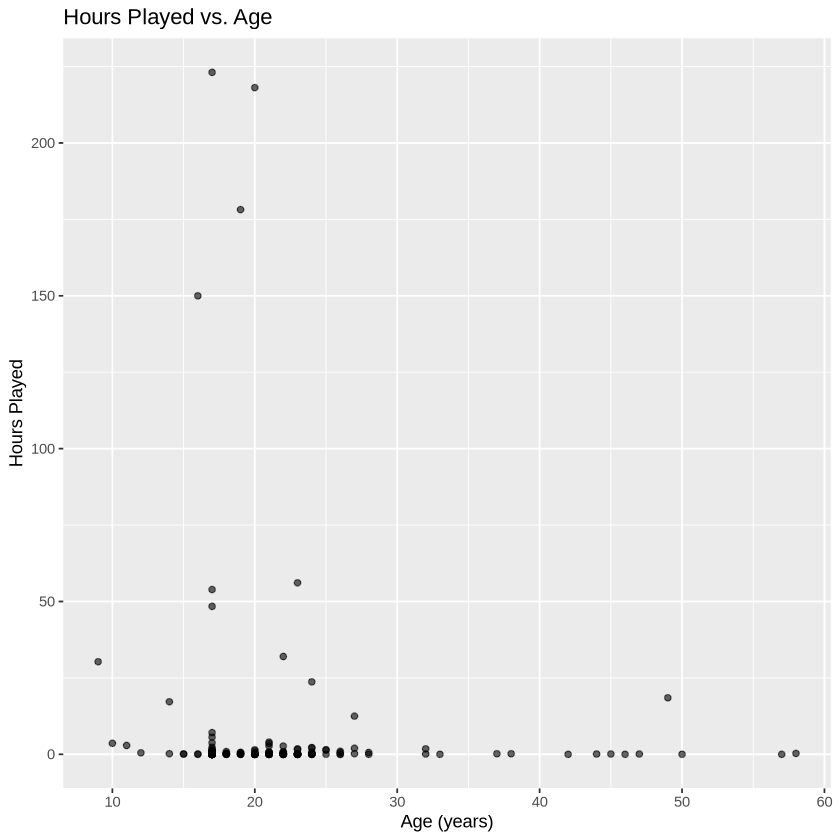

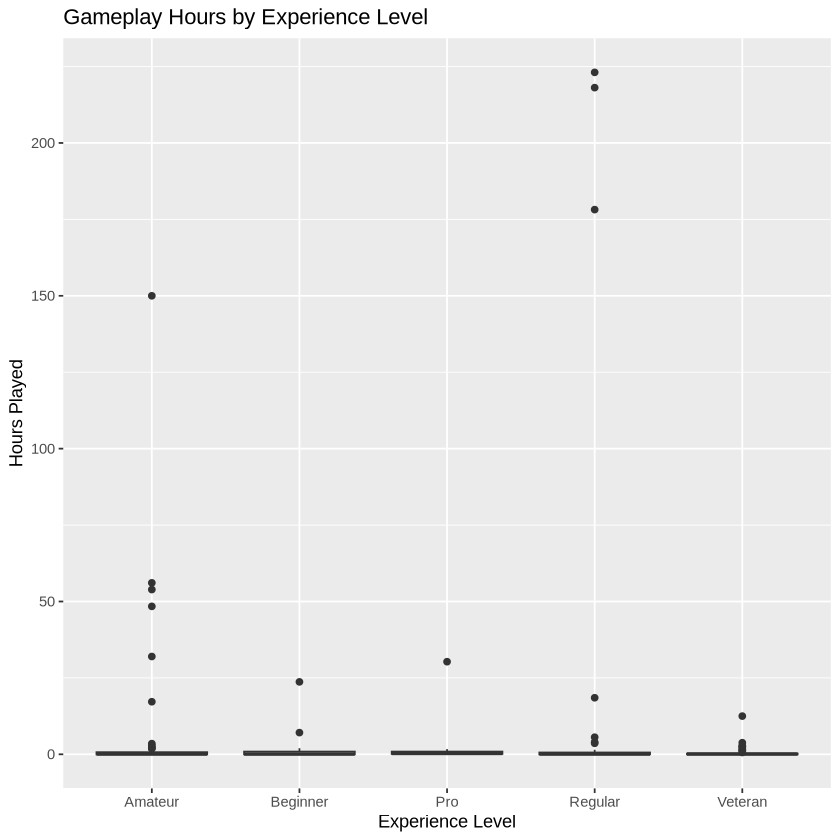

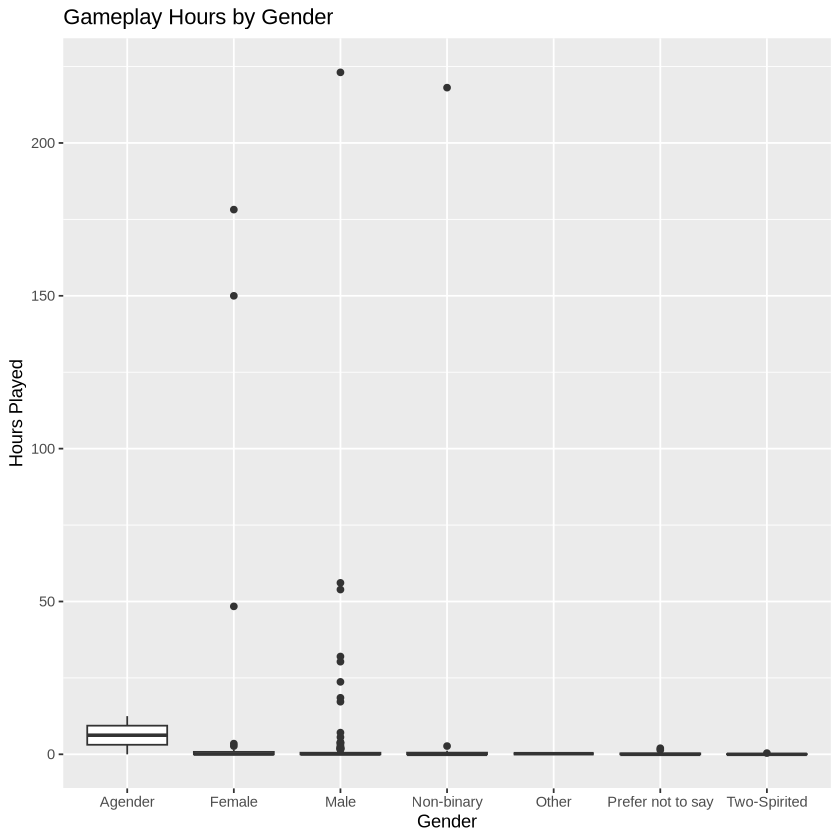

In [20]:
players = read_csv("players.csv")
players
sessions = read_csv("sessions.csv")
sessions

players_clean <- players |>
  clean_names() |>
  mutate(
    gender = as.factor(gender),
    experience = as.factor(experience),
    subscribe = as.factor(subscribe)
  )


numeric_means <- players_clean |>
  select(where(is.numeric)) |>
  summarise(across(everything(), mean, na.rm = TRUE)) |>
  pivot_longer(
    everything(),
    names_to = "variable",
    values_to = "mean_value"
  )

numeric_means
players_clean |>
  ggplot(aes(x = played_hours)) +
  geom_histogram(bins = 30) +
  labs(
    title = "Distribution of Total Gameplay Hours",
    x = "Hours Played",
    y = "Count of Players"
  )
players_clean |>
  ggplot(aes(x = age, y = played_hours)) +
  geom_point(alpha = 0.6) +
  labs(
    title = "Hours Played vs. Age",
    x = "Age (years)",
    y = "Hours Played"
  )
players_clean |>
  ggplot(aes(x = experience, y = played_hours)) +
  geom_boxplot() +
  labs(
    title = "Gameplay Hours by Experience Level",
    x = "Experience Level",
    y = "Hours Played"
  )
players_clean |>
  ggplot(aes(x = gender, y = played_hours)) +
  geom_boxplot() +
  labs(
    title = "Gameplay Hours by Gender",
    x = "Gender",
    y = "Hours Played"
  )
